In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import scipy.stats as stats

In [2]:
df = pd.read_csv(r'Bakery_sales.csv')

# EDA and Data Cleaning

In [3]:
df.head()

,Unnamed: 0,date,time,ticket_number,article,Quantity,unit_price
0,0,2021-01-02,08:38,150040.0,BAGUETTE,1.0,"0,90 €"
1,1,2021-01-02,08:38,150040.0,PAIN AU CHOCOLAT,3.0,"1,20 €"
2,4,2021-01-02,09:14,150041.0,PAIN AU CHOCOLAT,2.0,"1,20 €"
3,5,2021-01-02,09:14,150041.0,PAIN,1.0,"1,15 €"
4,8,2021-01-02,09:25,150042.0,TRADITIONAL BAGUETTE,5.0,"1,20 €"


In [4]:
df = df.iloc[0:,1:]

In [5]:
df.head()

,date,time,ticket_number,article,Quantity,unit_price
0,2021-01-02,08:38,150040.0,BAGUETTE,1.0,"0,90 €"
1,2021-01-02,08:38,150040.0,PAIN AU CHOCOLAT,3.0,"1,20 €"
2,2021-01-02,09:14,150041.0,PAIN AU CHOCOLAT,2.0,"1,20 €"
3,2021-01-02,09:14,150041.0,PAIN,1.0,"1,15 €"
4,2021-01-02,09:25,150042.0,TRADITIONAL BAGUETTE,5.0,"1,20 €"


In [6]:
df.rename(columns={'article':'item'},inplace=True)

In [7]:
df.head()

,date,time,ticket_number,item,Quantity,unit_price
0,2021-01-02,08:38,150040.0,BAGUETTE,1.0,"0,90 €"
1,2021-01-02,08:38,150040.0,PAIN AU CHOCOLAT,3.0,"1,20 €"
2,2021-01-02,09:14,150041.0,PAIN AU CHOCOLAT,2.0,"1,20 €"
3,2021-01-02,09:14,150041.0,PAIN,1.0,"1,15 €"
4,2021-01-02,09:25,150042.0,TRADITIONAL BAGUETTE,5.0,"1,20 €"


In [8]:
df.shape

(234005, 6)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234005 entries, 0 to 234004
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   date           234005 non-null  object 
 1   time           234005 non-null  object 
 2   ticket_number  234005 non-null  float64
 3   item           234005 non-null  object 
 4   Quantity       234005 non-null  float64
 5   unit_price     234005 non-null  object 
dtypes: float64(2), object(4)
memory usage: 10.7+ MB


In [10]:
df['date'] = pd.to_datetime(df['date'])

In [11]:
df.head()

,date,time,ticket_number,item,Quantity,unit_price
0,2021-01-02,08:38,150040.0,BAGUETTE,1.0,"0,90 €"
1,2021-01-02,08:38,150040.0,PAIN AU CHOCOLAT,3.0,"1,20 €"
2,2021-01-02,09:14,150041.0,PAIN AU CHOCOLAT,2.0,"1,20 €"
3,2021-01-02,09:14,150041.0,PAIN,1.0,"1,15 €"
4,2021-01-02,09:25,150042.0,TRADITIONAL BAGUETTE,5.0,"1,20 €"


In [12]:
df['unit_price'] = df['unit_price'].str.replace(',','.')
df['unit_price'] = df['unit_price'].replace('€','',regex=True)
df['unit_price']=df['unit_price'].astype('float')

In [13]:
df.head()

,date,time,ticket_number,item,Quantity,unit_price
0,2021-01-02,08:38,150040.0,BAGUETTE,1.0,0.90
1,2021-01-02,08:38,150040.0,PAIN AU CHOCOLAT,3.0,1.20
2,2021-01-02,09:14,150041.0,PAIN AU CHOCOLAT,2.0,1.20
3,2021-01-02,09:14,150041.0,PAIN,1.0,1.15
4,2021-01-02,09:25,150042.0,TRADITIONAL BAGUETTE,5.0,1.20


In [14]:
df[['Hour','Minute']] = df['time'].str.split(':',expand=True)

In [15]:
df.head()

,date,time,ticket_number,item,Quantity,unit_price,Hour,Minute
0,2021-01-02,08:38,150040.0,BAGUETTE,1.0,0.90,08,38
1,2021-01-02,08:38,150040.0,PAIN AU CHOCOLAT,3.0,1.20,08,38
2,2021-01-02,09:14,150041.0,PAIN AU CHOCOLAT,2.0,1.20,09,14
3,2021-01-02,09:14,150041.0,PAIN,1.0,1.15,09,14
4,2021-01-02,09:25,150042.0,TRADITIONAL BAGUETTE,5.0,1.20,09,25


In [16]:
df['Hour'] = pd.to_numeric(df['Hour'])
df['Minute'] = pd.to_numeric(df['Minute'])

In [17]:
df.head()

,date,time,ticket_number,item,Quantity,unit_price,Hour,Minute
0,2021-01-02,08:38,150040.0,BAGUETTE,1.0,0.90,8,38
1,2021-01-02,08:38,150040.0,PAIN AU CHOCOLAT,3.0,1.20,8,38
2,2021-01-02,09:14,150041.0,PAIN AU CHOCOLAT,2.0,1.20,9,14
3,2021-01-02,09:14,150041.0,PAIN,1.0,1.15,9,14
4,2021-01-02,09:25,150042.0,TRADITIONAL BAGUETTE,5.0,1.20,9,25


In [18]:
df['Week_Day'] = df['date'].dt.day_name()
df['Month'] = df['date'].dt.month_name()
df['year']  = df['date'].dt.year

In [19]:
df.head()

,date,time,ticket_number,item,Quantity,unit_price,Hour,Minute,Week_Day,Month,year
0,2021-01-02,08:38,150040.0,BAGUETTE,1.0,0.90,8,38,Saturday,January,2021
1,2021-01-02,08:38,150040.0,PAIN AU CHOCOLAT,3.0,1.20,8,38,Saturday,January,2021
2,2021-01-02,09:14,150041.0,PAIN AU CHOCOLAT,2.0,1.20,9,14,Saturday,January,2021
3,2021-01-02,09:14,150041.0,PAIN,1.0,1.15,9,14,Saturday,January,2021
4,2021-01-02,09:25,150042.0,TRADITIONAL BAGUETTE,5.0,1.20,9,25,Saturday,January,2021


In [20]:
df.drop(columns={'time'},inplace=True)

In [21]:
df.head()

,date,ticket_number,item,Quantity,unit_price,Hour,Minute,Week_Day,Month,year
0,2021-01-02,150040.0,BAGUETTE,1.0,0.90,8,38,Saturday,January,2021
1,2021-01-02,150040.0,PAIN AU CHOCOLAT,3.0,1.20,8,38,Saturday,January,2021
2,2021-01-02,150041.0,PAIN AU CHOCOLAT,2.0,1.20,9,14,Saturday,January,2021
3,2021-01-02,150041.0,PAIN,1.0,1.15,9,14,Saturday,January,2021
4,2021-01-02,150042.0,TRADITIONAL BAGUETTE,5.0,1.20,9,25,Saturday,January,2021


In [22]:
for i in df.columns:
    print(df[i].name)
    print(df[i].unique())

date
<DatetimeArray>
['2021-01-02 00:00:00', '2021-01-03 00:00:00', '2021-01-04 00:00:00',
 '2021-01-05 00:00:00', '2021-01-07 00:00:00', '2021-01-08 00:00:00',
 '2021-01-09 00:00:00', '2021-01-10 00:00:00', '2021-01-11 00:00:00',
 '2021-01-12 00:00:00',
 ...
 '2022-09-21 00:00:00', '2022-09-22 00:00:00', '2022-09-23 00:00:00',
 '2022-09-24 00:00:00', '2022-09-25 00:00:00', '2022-09-26 00:00:00',
 '2022-09-27 00:00:00', '2022-09-28 00:00:00', '2022-09-29 00:00:00',
 '2022-09-30 00:00:00']
Length: 600, dtype: datetime64[ns]
ticket_number
[150040. 150041. 150042. ... 288911. 288912. 288913.]
item
['BAGUETTE' 'PAIN AU CHOCOLAT' 'PAIN' 'TRADITIONAL BAGUETTE' 'CROISSANT'
 'BANETTE' 'BANETTINE' 'SPECIAL BREAD' 'COUPE' 'SAND JB EMMENTAL'
 'KOUIGN AMANN' 'BOULE 200G' 'BOULE 400G' 'GAL FRANGIPANE 6P' 'CAMPAGNE'
 'MOISSON' 'CAFE OU EAU' 'BRIOCHE' 'CEREAL BAGUETTE' 'SEIGLE' 'COMPLET'
 'DIVERS PATISSERIE' 'GAL FRANGIPANE 4P' 'COOKIE' 'FICELLE'
 'PAIN AUX RAISINS' 'GAL POMME 6P' 'GAL POMME 4P' 'FIN

In [23]:
df[df['Quantity']<0]

,date,ticket_number,item,Quantity,unit_price,Hour,Minute,Week_Day,Month,year
448,2021-01-03,150265.0,BAGUETTE,-1.0,0.90,10,41,Sunday,January,2021
1162,2021-01-05,150738.0,SPECIAL BREAD,-1.0,2.40,19,0,Tuesday,January,2021
1163,2021-01-05,150738.0,DIVERS PATISSERIE,-1.0,6.00,19,0,Tuesday,January,2021
1164,2021-01-05,150738.0,DIVERS BOULANGERIE,-1.0,2.00,19,0,Tuesday,January,2021
1467,2021-01-08,150941.0,COUPE,-1.0,0.15,11,58,Friday,January,2021
...,...,...,...,...,...,...,...,...,...,...
233054,2022-09-27,288312.0,COUPE,-2.0,0.15,18,3,Tuesday,September,2022
233055,2022-09-27,288312.0,TRADITIONAL BAGUETTE,-1.0,1.30,18,3,Tuesday,September,2022
233056,2022-09-27,288312.0,CEREAL BAGUETTE,-3.0,1.35,18,3,Tuesday,September,2022
233553,2022-09-29,288639.0,BOISSON 33CL,-1.0,1.50,11,55,Thursday,September,2022


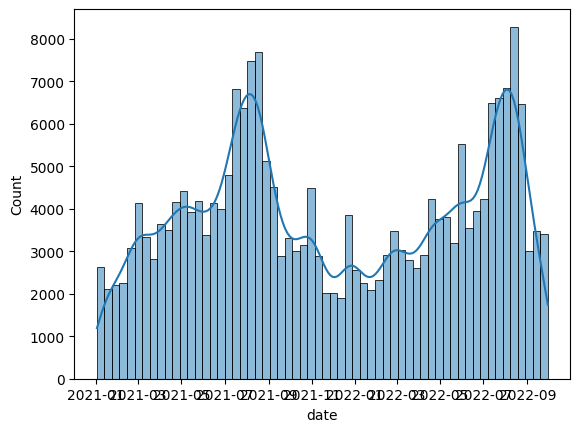

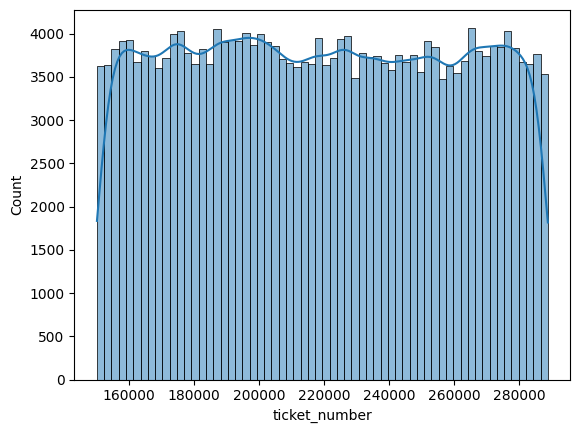

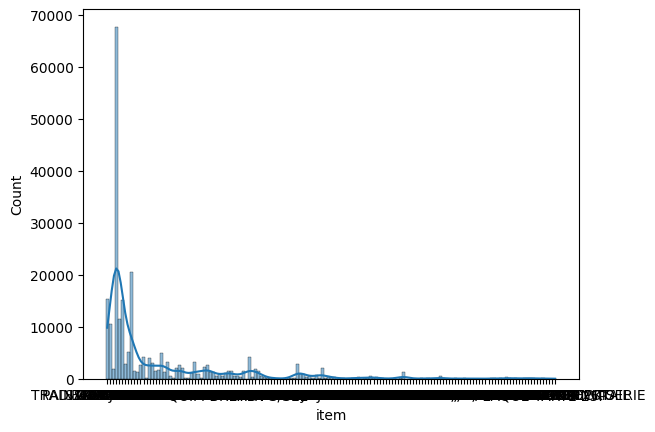

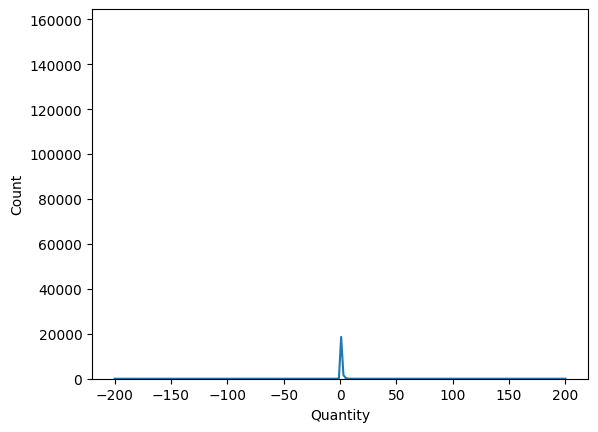

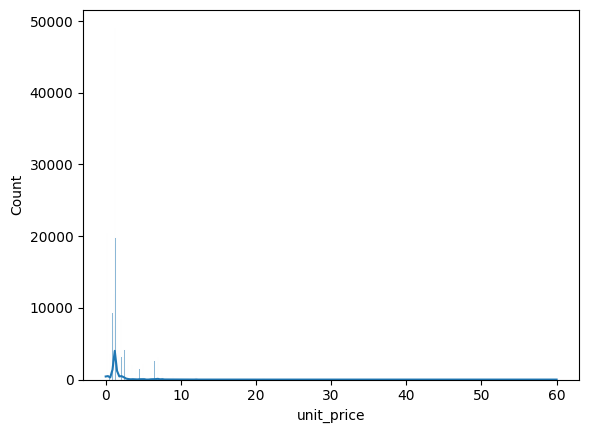

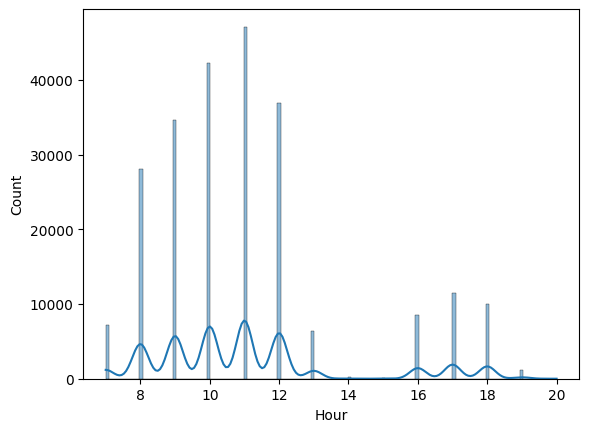

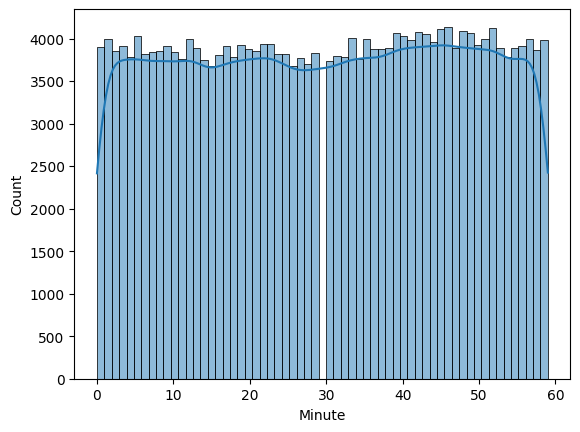

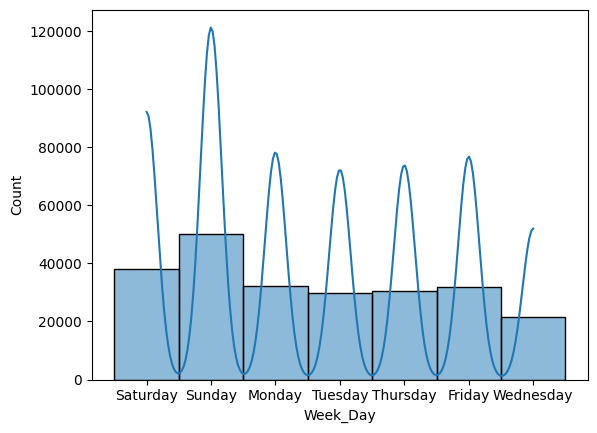

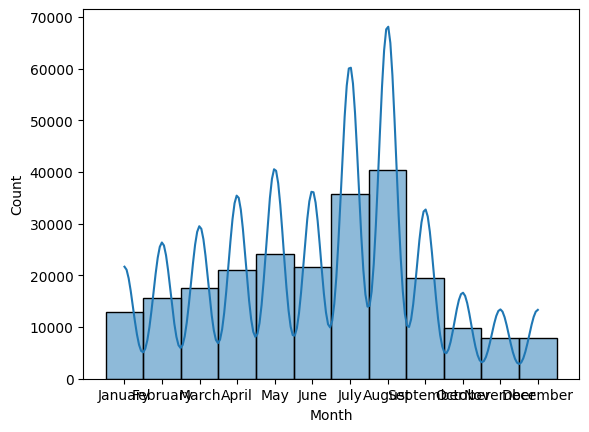

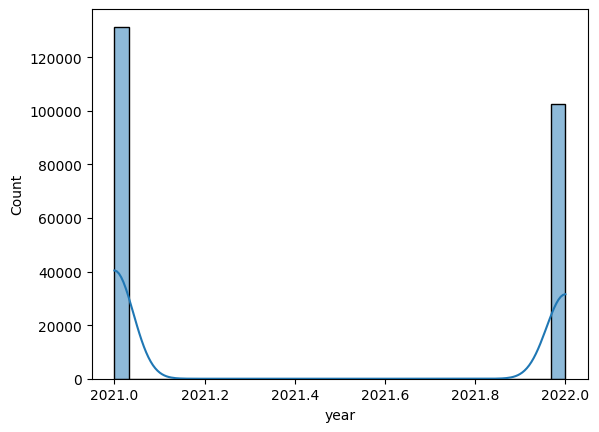

In [24]:
for i in df.columns:
  sns.histplot(data=df,x=i,kde=True)
  plt.show()

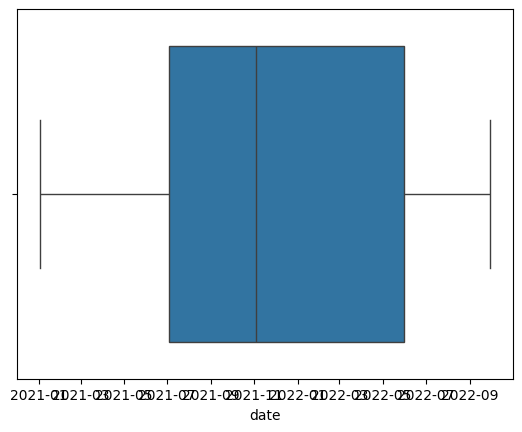

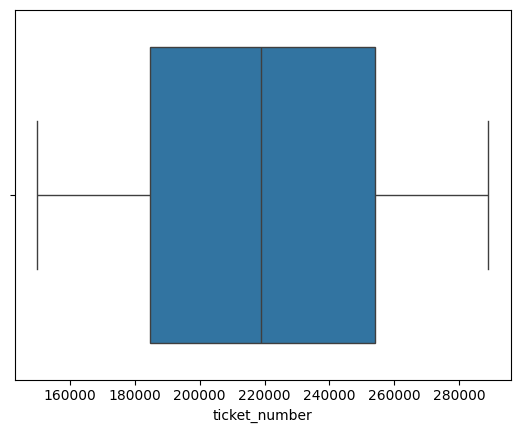

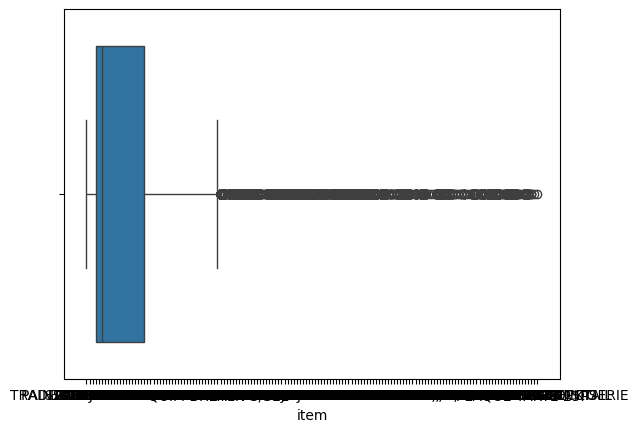

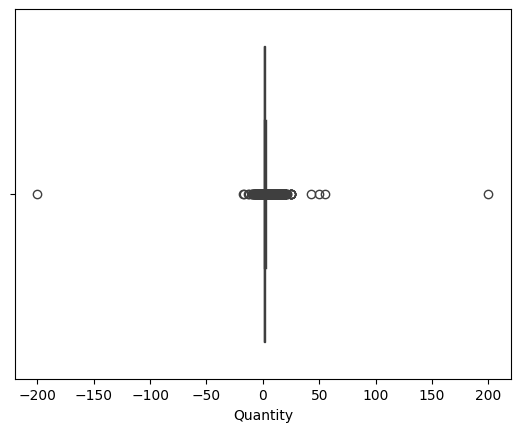

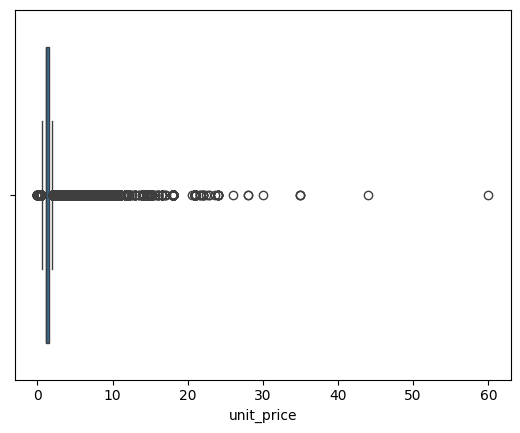

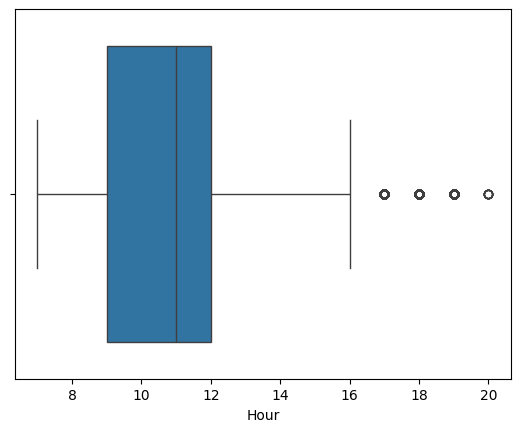

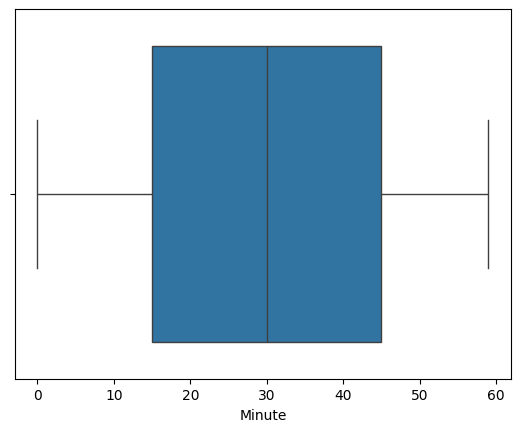

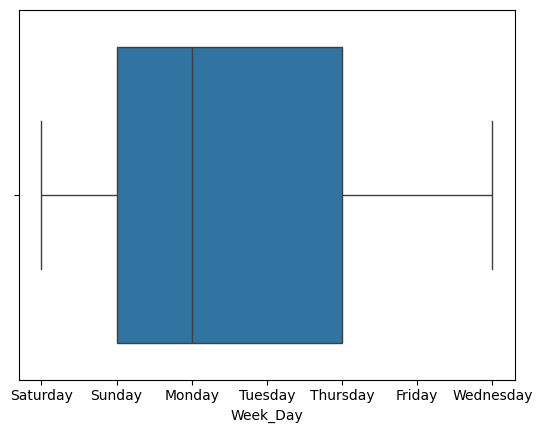

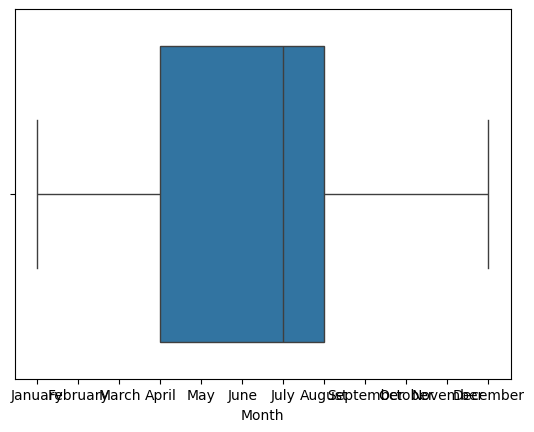

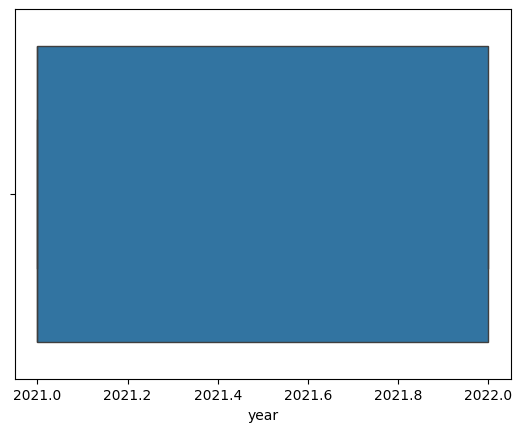

In [25]:
for i in df.columns:
  sns.boxplot(data=df,x=i)
  plt.show()

In [26]:
df.describe()

,date,ticket_number,Quantity,unit_price,Hour,Minute,year
count,234005,234005.000000,234005.000000,234005.000000,234005.000000,234005.000000,234005.000000
mean,2021-11-30 11:33:31.049336576,219201.258738,1.538377,1.662195,11.072037,29.692348,2021.438388
min,2021-01-02 00:00:00,150040.000000,-200.000000,0.000000,7.000000,0.000000,2021.000000
25%,2021-07-03 00:00:00,184754.000000,1.000000,1.100000,9.000000,15.000000,2021.000000
50%,2021-11-04 00:00:00,218807.000000,1.000000,1.200000,11.000000,30.000000,2021.000000
75%,2022-05-31 00:00:00,253927.000000,2.000000,1.500000,12.000000,45.000000,2022.000000
max,2022-09-30 00:00:00,288913.000000,200.000000,60.000000,20.000000,59.000000,2022.000000
std,NaN,40053.223896,1.289603,1.722720,2.774393,17.359653,0.496191


In [27]:
df[df['Quantity']>0]

,date,ticket_number,item,Quantity,unit_price,Hour,Minute,Week_Day,Month,year
0,2021-01-02,150040.0,BAGUETTE,1.0,0.90,8,38,Saturday,January,2021
1,2021-01-02,150040.0,PAIN AU CHOCOLAT,3.0,1.20,8,38,Saturday,January,2021
2,2021-01-02,150041.0,PAIN AU CHOCOLAT,2.0,1.20,9,14,Saturday,January,2021
3,2021-01-02,150041.0,PAIN,1.0,1.15,9,14,Saturday,January,2021
4,2021-01-02,150042.0,TRADITIONAL BAGUETTE,5.0,1.20,9,25,Saturday,January,2021
...,...,...,...,...,...,...,...,...,...,...
234000,2022-09-30,288911.0,COUPE,1.0,0.15,18,52,Friday,September,2022
234001,2022-09-30,288911.0,BOULE 200G,1.0,1.20,18,52,Friday,September,2022
234002,2022-09-30,288911.0,COUPE,2.0,0.15,18,52,Friday,September,2022
234003,2022-09-30,288912.0,TRADITIONAL BAGUETTE,1.0,1.30,18,55,Friday,September,2022


In [28]:
q1 = df['Quantity'].quantile(0.25)
q3 = df['Quantity'].quantile(0.75)
IQR = q3-q1
lower_bound = q1-1.5*IQR
upper_bound = q3+1.5*IQR

In [29]:
df = df[(df['Quantity']>=lower_bound) & (df['Quantity']<=upper_bound)]

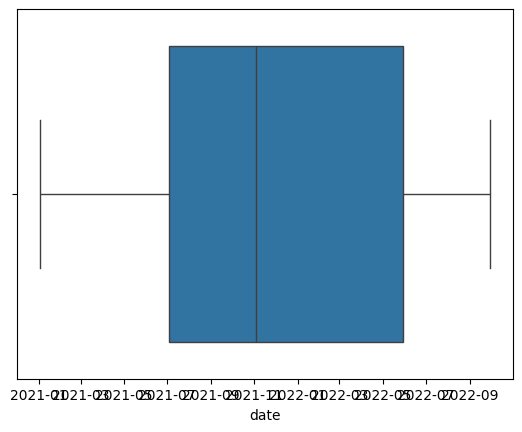

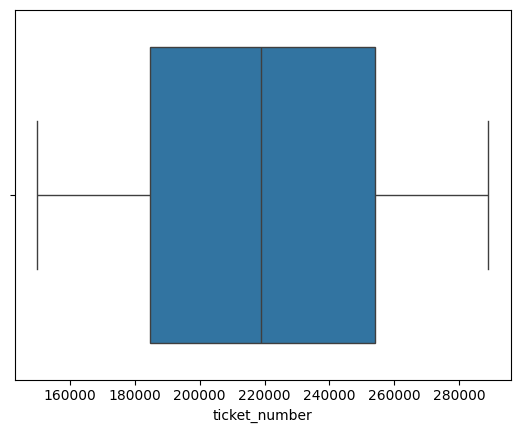

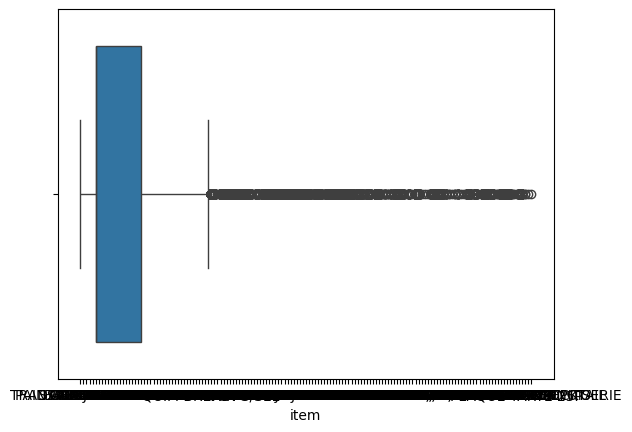

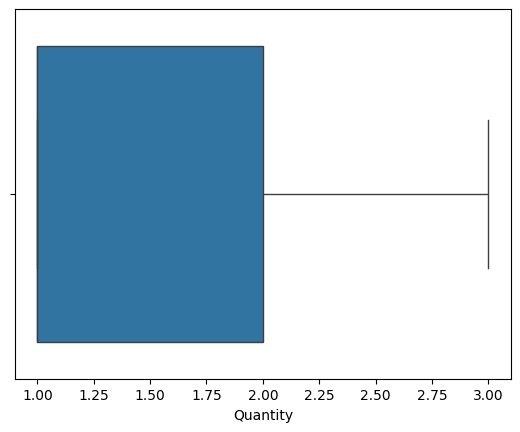

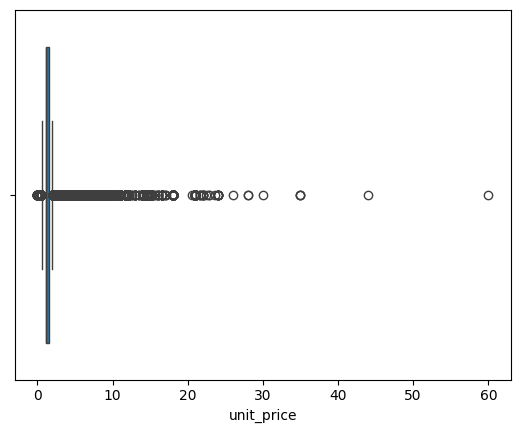

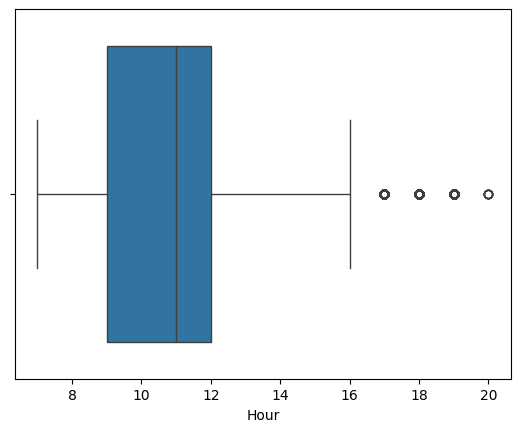

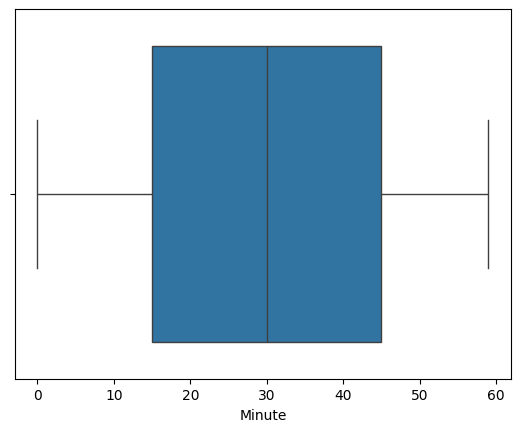

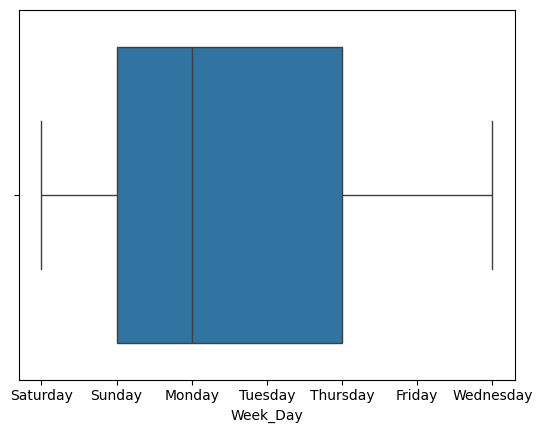

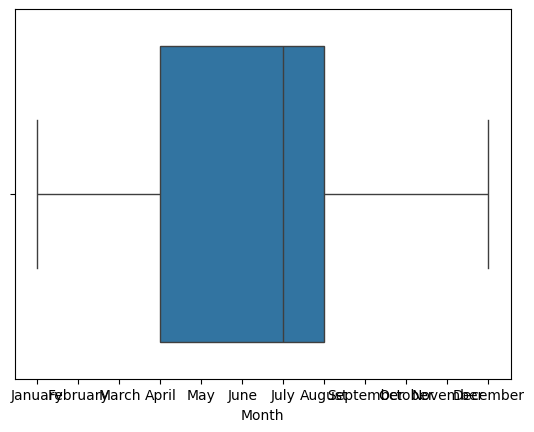

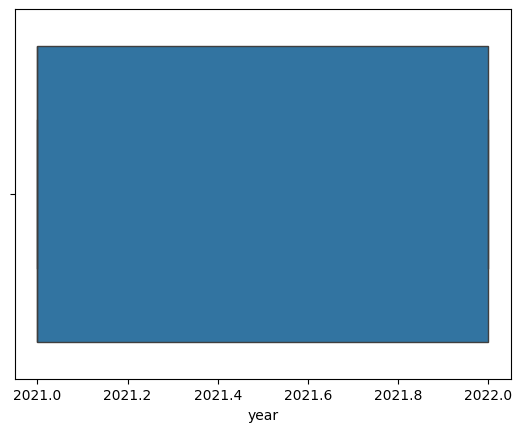

In [30]:
for i in df.columns:
  sns.boxplot(data=df,x=i)
  plt.show()

In [31]:
df.head()

,date,ticket_number,item,Quantity,unit_price,Hour,Minute,Week_Day,Month,year
0,2021-01-02,150040.0,BAGUETTE,1.0,0.90,8,38,Saturday,January,2021
1,2021-01-02,150040.0,PAIN AU CHOCOLAT,3.0,1.20,8,38,Saturday,January,2021
2,2021-01-02,150041.0,PAIN AU CHOCOLAT,2.0,1.20,9,14,Saturday,January,2021
3,2021-01-02,150041.0,PAIN,1.0,1.15,9,14,Saturday,January,2021
5,2021-01-02,150043.0,BAGUETTE,2.0,0.90,9,25,Saturday,January,2021


In [32]:
df['Revenue'] = df['unit_price']*df['Quantity']

In [33]:
df.head()

,date,ticket_number,item,Quantity,unit_price,Hour,Minute,Week_Day,Month,year,Revenue
0,2021-01-02,150040.0,BAGUETTE,1.0,0.90,8,38,Saturday,January,2021,0.90
1,2021-01-02,150040.0,PAIN AU CHOCOLAT,3.0,1.20,8,38,Saturday,January,2021,3.60
2,2021-01-02,150041.0,PAIN AU CHOCOLAT,2.0,1.20,9,14,Saturday,January,2021,2.40
3,2021-01-02,150041.0,PAIN,1.0,1.15,9,14,Saturday,January,2021,1.15
5,2021-01-02,150043.0,BAGUETTE,2.0,0.90,9,25,Saturday,January,2021,1.80


# KPI's

In [34]:
### Total Orders
df['ticket_number'].shape[0]

219756

In [35]:
### Average Qunatity 
df['Quantity'].mean()

np.float64(1.3491190229163255)

In [36]:
# Total Revenue 
df['Revenue'].sum()

np.float64(478662.69999999995)

In [37]:
### Average Ticket Size
df['Revenue'].sum()/len(df['ticket_number'].unique())

np.float64(3.665778550422742)

# In Depth Analysis

In [38]:
df.head()

,date,ticket_number,item,Quantity,unit_price,Hour,Minute,Week_Day,Month,year,Revenue
0,2021-01-02,150040.0,BAGUETTE,1.0,0.90,8,38,Saturday,January,2021,0.90
1,2021-01-02,150040.0,PAIN AU CHOCOLAT,3.0,1.20,8,38,Saturday,January,2021,3.60
2,2021-01-02,150041.0,PAIN AU CHOCOLAT,2.0,1.20,9,14,Saturday,January,2021,2.40
3,2021-01-02,150041.0,PAIN,1.0,1.15,9,14,Saturday,January,2021,1.15
5,2021-01-02,150043.0,BAGUETTE,2.0,0.90,9,25,Saturday,January,2021,1.80


<Axes: >

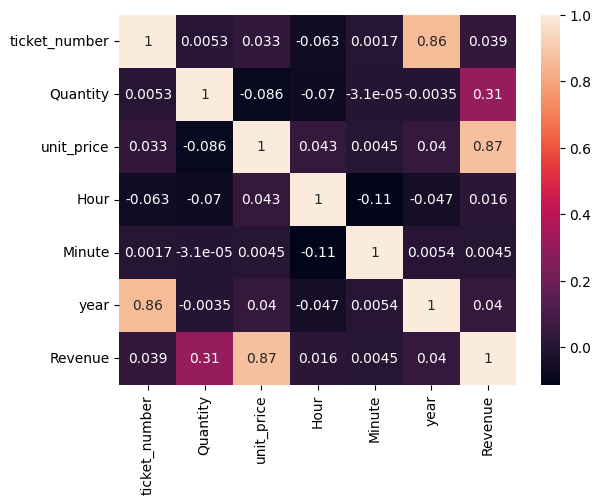

In [39]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [40]:
df.head()

,date,ticket_number,item,Quantity,unit_price,Hour,Minute,Week_Day,Month,year,Revenue
0,2021-01-02,150040.0,BAGUETTE,1.0,0.90,8,38,Saturday,January,2021,0.90
1,2021-01-02,150040.0,PAIN AU CHOCOLAT,3.0,1.20,8,38,Saturday,January,2021,3.60
2,2021-01-02,150041.0,PAIN AU CHOCOLAT,2.0,1.20,9,14,Saturday,January,2021,2.40
3,2021-01-02,150041.0,PAIN,1.0,1.15,9,14,Saturday,January,2021,1.15
5,2021-01-02,150043.0,BAGUETTE,2.0,0.90,9,25,Saturday,January,2021,1.80


#  Top Products

In [69]:
### Most Selling Item ###
Top_20_Most_Selling_Items = df.groupby('item').agg({'ticket_number':'count','unit_price':'mean'}).reset_index().sort_values(by='ticket_number',ascending=False).head(10)
Top_20_Least_Selling_Items = df.groupby('item').agg({'ticket_number':'count','unit_price':'mean'}).reset_index().sort_values(by='ticket_number',ascending=True).head(10)

In [70]:
Top_20_Most_Selling_Items

,item,ticket_number,unit_price
140,TRADITIONAL BAGUETTE,62679,1.232146
31,COUPE,20229,0.150000
4,BAGUETTE,14545,0.929185
7,BANETTE,14342,1.080264
32,CROISSANT,8762,1.132527
85,PAIN AU CHOCOLAT,8482,1.232569
126,SPECIAL BREAD,5149,2.459060
25,CEREAL BAGUETTE,4693,1.275698
57,FORMULE SANDWICH,4037,6.704607
12,BOULE 400G,4033,1.560724


In [71]:
Top_20_Least_Selling_Items

,item,ticket_number,unit_price
3,ARTICLE 295,1,0.0
22,CAKE,1,3.0
20,BUCHE 8PERS,1,28.0
35,CRUMBLECARAMEL OU PISTAE,1,6.0
45,DOUCEUR D HIVER,1,3.0
100,PLAT 6.50E,1,6.5
105,"PLATPREPARE6,00",1,6.0
91,PAIN NOIR,1,0.6
119,SACHET DE VIENNOISERIE,1,4.0
112,REDUCTION SUCREES 24,1,15.0


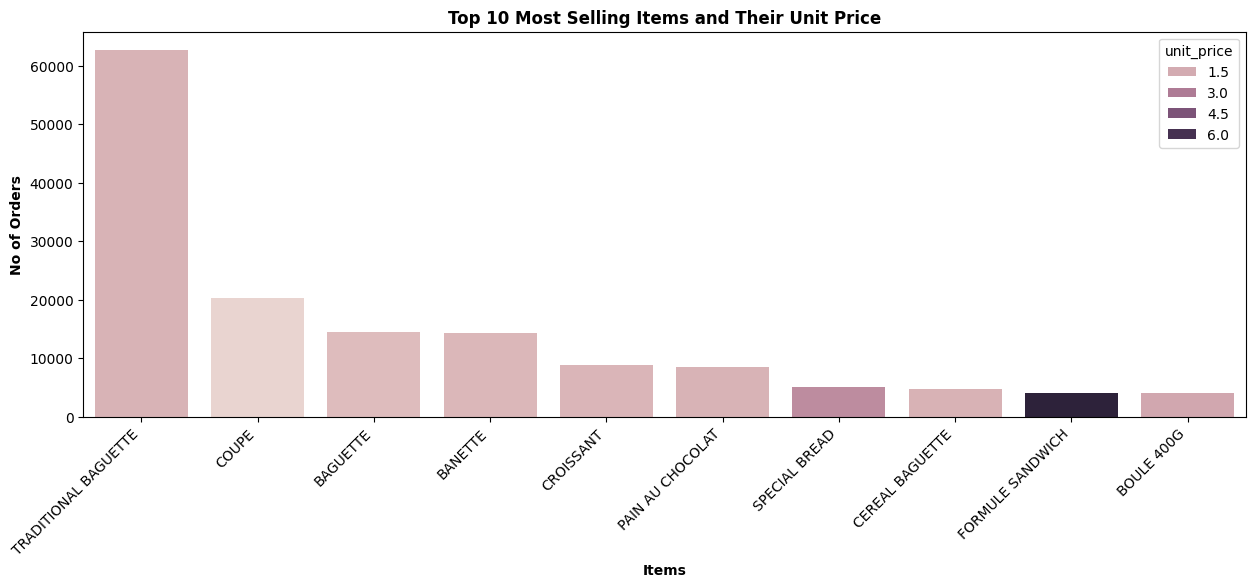

In [74]:
plt.figure(figsize=(15, 5))  # Reduce figure width
plt.title('Top 10 Most Selling Items and Their Unit Price', fontdict={'fontweight': 'bold'})
plt.xlabel('Items', fontdict={'fontweight': 'bold'})
plt.ylabel('No of Orders', fontdict={'fontweight': 'bold'})

sns.barplot(data=Top_20_Most_Selling_Items, x='item', y='ticket_number', hue='unit_price')

plt.xticks(rotation=45, ha='right')  # Tilt x-axis labels
plt.show()

This chart represents the **Top 10 Most Selling Items** along with their **Unit Price**.

### **Key Observations:**
- **Traditional Baguette dominates sales**, significantly outpacing other items.
- Other popular items include **Coupe, Baguette, Banette, and Croissant**—indicating strong customer demand for bakery staples.
- The **unit price is shaded**, with darker shades representing higher prices.
- Most of these top-selling items seem to have **relatively lower unit prices**, which could contribute to their high sales volume.

### **Business Insights:**
1. **Product Demand**: The dominance of bread-related items suggests **a strong customer preference for bakery staples**.
2. **Pricing Strategy**: Most **high-selling products have a low unit price**, reinforcing the idea that affordability drives demand.
3. **Upselling Opportunities**: Since these items are highly popular, consider **bundling them with less popular or higher-margin products**.
4. **Stock and Supply Chain Optimization**: Ensuring a **steady supply of these top items** will help maintain customer satisfaction and revenue.

Would you like a **price vs. sales correlation analysis** to determine how pricing influences sales volume across different products? 📊

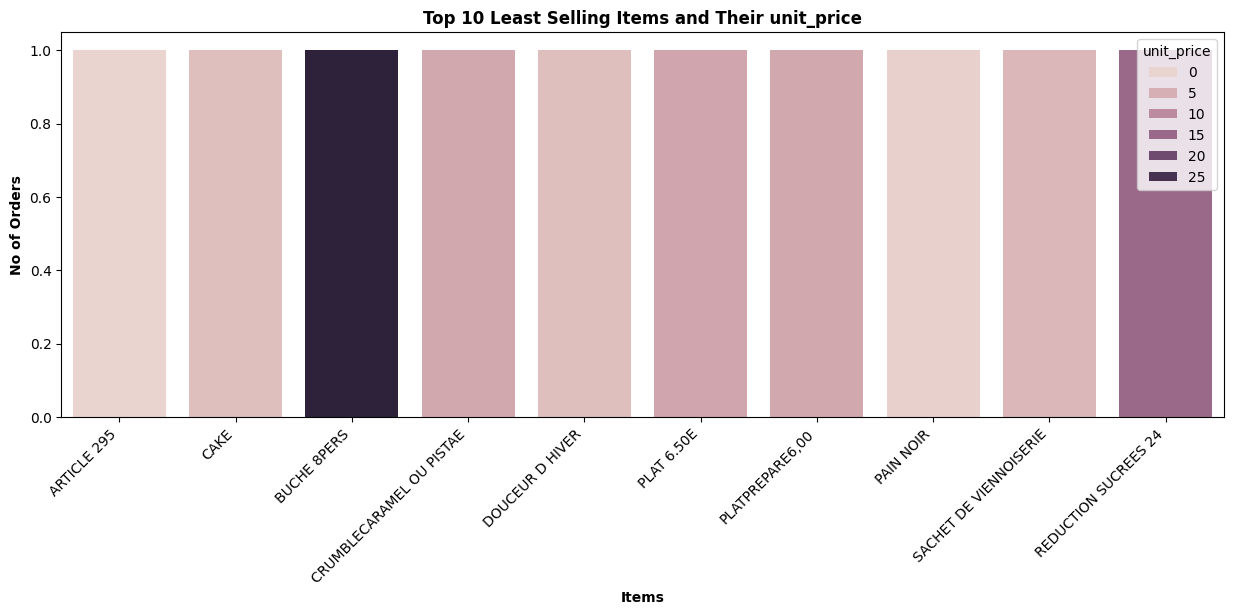

In [75]:
plt.figure(figsize=(15,5))
plt.title('Top 10 Least Selling Items and Their unit_price',fontdict={'fontweight':'bold'})
plt.xlabel('Items',fontdict={'fontweight':'bold'})
plt.ylabel('No of Orders',fontdict={'fontweight':'bold'})
sns.barplot(data=Top_20_Least_Selling_Items,x='item',y='ticket_number',hue='unit_price')

plt.xticks(rotation=45, ha='right')
plt.show()

This bar chart represents the **Top 10 Least Selling Items** along with their **Unit Price**.

### **Key Observations:**
- **All items have very few orders**, likely indicating low demand.
- The **unit price is represented using different shades**; darker shades indicate higher prices.
- Some of these items may have a **higher unit price**, potentially affecting sales.
- Certain **food items like cakes, tarts, and prepared plates appear in the least-selling list**, which might indicate customer preferences shifting away from these.

### **Possible Business Insights:**
1. **Price Sensitivity**: If higher-priced items are among the least sold, consider price adjustments or promotions to boost sales.
2. **Customer Preferences**: Conduct a **survey or review customer feedback** to determine why these items aren’t performing well.
3. **Marketing Strategies**: Promote these products through **discounts, bundling with popular items, or better placement in-store/online**.
4. **Seasonality Check**: Some items may have **low sales due to seasonal trends**. Analyzing sales over time can confirm this.

Would you like a **detailed correlation between unit price and sales volume** to identify if pricing is a major factor? 📊

In [46]:
df.head()

,date,ticket_number,item,Quantity,unit_price,Hour,Minute,Week_Day,Month,year,Revenue
0,2021-01-02,150040.0,BAGUETTE,1.0,0.90,8,38,Saturday,January,2021,0.90
1,2021-01-02,150040.0,PAIN AU CHOCOLAT,3.0,1.20,8,38,Saturday,January,2021,3.60
2,2021-01-02,150041.0,PAIN AU CHOCOLAT,2.0,1.20,9,14,Saturday,January,2021,2.40
3,2021-01-02,150041.0,PAIN,1.0,1.15,9,14,Saturday,January,2021,1.15
5,2021-01-02,150043.0,BAGUETTE,2.0,0.90,9,25,Saturday,January,2021,1.80


# Total Revenue and Total Units Sold Each Year

In [47]:
Revenue_Each_Year = df.groupby('year').agg({'Revenue':'sum','Quantity':'sum'}).reset_index()

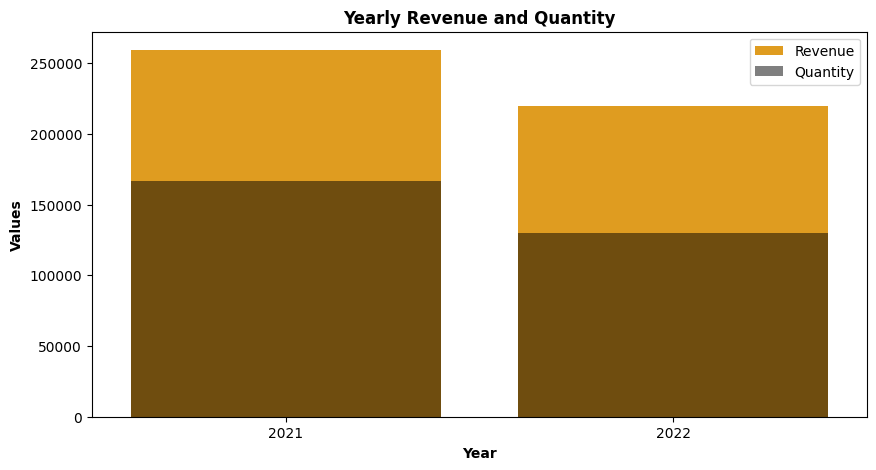

In [48]:

plt.figure(figsize=(10, 5))
sns.barplot(x='year', y='Revenue', data=Revenue_Each_Year, color='orange', label='Revenue')
sns.barplot(x='year', y='Quantity', data=Revenue_Each_Year, color='black', alpha=0.5, label='Quantity')
plt.xlabel('Year',fontdict={'fontweight':'bold'})
plt.ylabel('Values',fontdict={'fontweight':'bold'})
plt.title('Yearly Revenue and Quantity',fontdict={'fontweight':'bold'})
plt.legend()
plt.show()

This stacked bar chart represents **Yearly Revenue and Quantity** for **2021 and 2022**. Here are the key takeaways:

### **1️⃣ Revenue vs. Quantity Comparison**
- **2021 had higher revenue** compared to 2022.
- **Quantity sold also decreased in 2022**, though not as significantly as revenue.
- The **gap between revenue and quantity is larger in 2021**, indicating that either higher-priced products were sold or prices were increased in that year.

### **2️⃣ Possible Explanations for the Drop in 2022**
- **Lower demand or market conditions**: Fewer units sold in 2022 could indicate decreased customer demand.
- **Discounts or price reductions**: If the revenue dropped more than the quantity, it could mean products were sold at lower prices in 2022.
- **Product mix changes**: A shift toward lower-priced products in 2022 could also explain the revenue dip.

### **3️⃣ Business Insights & Next Steps**
- **Pricing Strategy Review**: Was there a price reduction in 2022 that led to lower revenue? Analyzing per-unit pricing could clarify this.
- **Customer & Market Trends**: Did customer preferences change? Did competitors introduce new products affecting demand?
- **Promotions & Discounts Impact**: If discounts were higher in 2022, it’s important to assess their impact on sales volume and revenue.

Would you like to break this down further, maybe by **quarterly revenue trends** or **product categories**? 🚀

# Sales Trend By WeekDay, Hour and Month


In [49]:
df.head()

,date,ticket_number,item,Quantity,unit_price,Hour,Minute,Week_Day,Month,year,Revenue
0,2021-01-02,150040.0,BAGUETTE,1.0,0.90,8,38,Saturday,January,2021,0.90
1,2021-01-02,150040.0,PAIN AU CHOCOLAT,3.0,1.20,8,38,Saturday,January,2021,3.60
2,2021-01-02,150041.0,PAIN AU CHOCOLAT,2.0,1.20,9,14,Saturday,January,2021,2.40
3,2021-01-02,150041.0,PAIN,1.0,1.15,9,14,Saturday,January,2021,1.15
5,2021-01-02,150043.0,BAGUETTE,2.0,0.90,9,25,Saturday,January,2021,1.80


In [50]:
Sales_Trend_By_WeekDay = df.groupby('Week_Day').agg({'ticket_number':'count','unit_price':'mean'}).reset_index().sort_values(by='ticket_number',ascending=False)

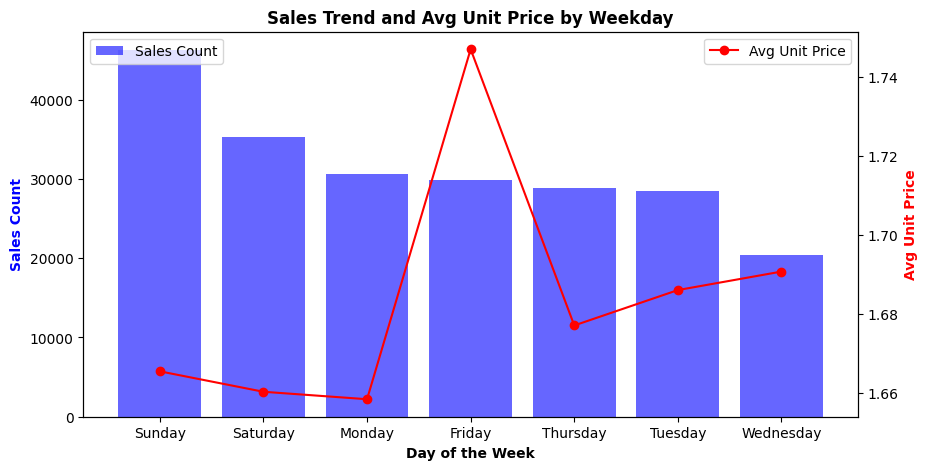

In [51]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax2 = ax1.twinx()
ax1.bar(Sales_Trend_By_WeekDay['Week_Day'], Sales_Trend_By_WeekDay['ticket_number'], color='blue', alpha=0.6, label='Sales Count')
ax2.plot(Sales_Trend_By_WeekDay['Week_Day'], Sales_Trend_By_WeekDay['unit_price'], marker='o', color='red', label='Avg Unit Price')

ax1.set_xlabel('Day of the Week',fontdict={'fontweight':'bold'})
ax1.set_ylabel('Sales Count', color='blue',fontdict={'fontweight':'bold'})
ax2.set_ylabel('Avg Unit Price', color='red',fontdict={'fontweight':'bold'})

plt.title('Sales Trend and Avg Unit Price by Weekday',fontdict={'fontweight':'bold'})
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()


This chart displays **Sales Count** (blue bars) and **Average Unit Price** (red line) by **day of the week**. Here are the key takeaways:

### **1️⃣ Sales Trends by Weekday**
- **Highest Sales**: **Sunday** has the highest number of transactions.
- **Strong Sales**: **Saturday, Monday, and Friday** also have relatively high sales.
- **Lower Sales**: **Wednesday has the lowest sales**, followed by **Tuesday and Thursday**.

### **2️⃣ Pricing Patterns**
- **Highest Average Unit Price**: **Friday** shows a significant spike in **unit price**, while sales volume is moderate.
- **Lowest Average Unit Price**: **Monday and Sunday** have the lowest prices, which might indicate promotions or discounts driving higher sales.

### **3️⃣ Business Insights**
- **Weekend Demand**: High sales on **Saturday and Sunday** suggest these are peak shopping days. Consider promotions or bundling deals to maximize revenue.
- **Friday Price Surge**: The **price spike on Friday** could mean:
  - Premium-priced items are sold more.
  - Price hikes before the weekend when demand is expected to increase.
  - Fewer discounts or promotional offers.
- **Midweek Sales Strategy**: Since **Wednesday and Thursday** have lower sales, consider introducing **midweek promotions** to boost revenue.

Would you like to analyze this further by breaking it down into **specific product categories**? 🚀

In [52]:
Sales_Trend_By_Hour = df.groupby('Hour').agg({'ticket_number':'count','unit_price':'mean'}).reset_index().sort_values(by='ticket_number',ascending=False)

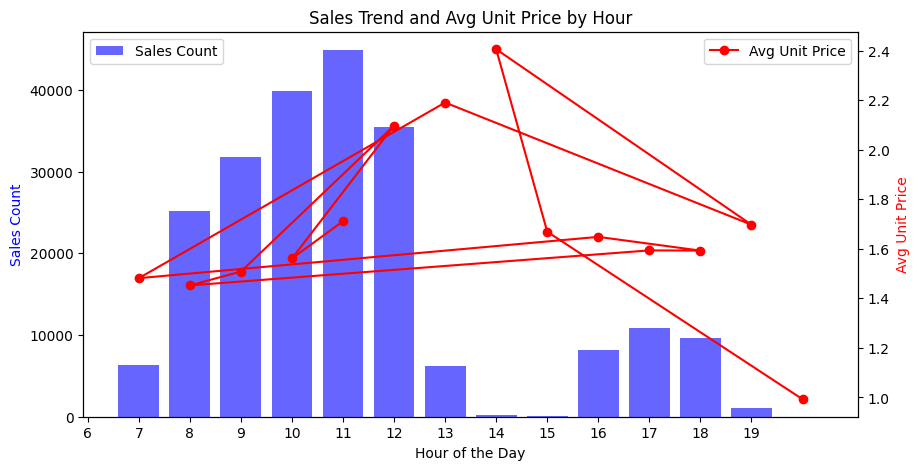

In [53]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax2 = ax1.twinx()
ax1.bar(Sales_Trend_By_Hour['Hour'], Sales_Trend_By_Hour['ticket_number'], color='blue', alpha=0.6, label='Sales Count')
ax2.plot(Sales_Trend_By_Hour['Hour'], Sales_Trend_By_Hour['unit_price'], marker='o', color='red', label='Avg Unit Price')

ax1.set_xlabel('Hour of the Day')
ax1.set_ylabel('Sales Count', color='blue')
ax2.set_ylabel('Avg Unit Price', color='red')

plt.title('Sales Trend and Avg Unit Price by Hour')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.xticks(range(6, 20))
plt.show()


This visualization shows **Sales Count** (blue bars) and **Average Unit Price** (red line) by hour of the day. Here are some key insights:

### **1️⃣ Peak Sales Hours**
- **Highest Sales**: Between **10 AM and 12 PM**, with the peak at **12 PM**.
- **Moderate Sales**: Between **8 AM to 9 AM** and **3 PM to 6 PM**.
- **Lowest Sales**: (at 7 am and then  2 , 3 ,7 PM ) 

### **2️⃣ Price Fluctuations**
- **Highest Average Price**: Around **2 PM**, but it does not correlate with high sales.
- **Stable Prices**: Between **8 AM and 12 PM**, which aligns with peak sales.
- **Price Drop in Late Evening**: The **lowest unit price** is after 8 PM, potentially due to discounts or clearance sales.

### **3️⃣ Business Insights**
- **Optimal Pricing Strategy**: Prices are high around 2 PM, but sales are low. Consider adjusting pricing to boost sales in the afternoon.
- **Promotion Opportunities**: If the 10 AM - 12 PM slot is the busiest, offering bundle deals or upselling could maximize revenue.
- **Evening Discount Strategy**: If prices drop at night, this could indicate **end-of-day promotions** or **lower demand**.

Would you like a deeper breakdown, such as **weekdays vs. weekends trends**? 🚀

In [54]:
df.head()

,date,ticket_number,item,Quantity,unit_price,Hour,Minute,Week_Day,Month,year,Revenue
0,2021-01-02,150040.0,BAGUETTE,1.0,0.90,8,38,Saturday,January,2021,0.90
1,2021-01-02,150040.0,PAIN AU CHOCOLAT,3.0,1.20,8,38,Saturday,January,2021,3.60
2,2021-01-02,150041.0,PAIN AU CHOCOLAT,2.0,1.20,9,14,Saturday,January,2021,2.40
3,2021-01-02,150041.0,PAIN,1.0,1.15,9,14,Saturday,January,2021,1.15
5,2021-01-02,150043.0,BAGUETTE,2.0,0.90,9,25,Saturday,January,2021,1.80


In [55]:
Sales_Trend_By_Month = df.groupby('Month').agg({'ticket_number':'count','unit_price':'mean'}).reset_index().sort_values(by='ticket_number',ascending=False)

In [56]:
Sales_Trend_By_Month

,Month,ticket_number,unit_price
1,August,37548,1.654020
5,July,33405,1.678315
8,May,22468,1.723838
6,June,20411,1.652690
0,April,19711,1.695320
11,September,18522,1.649633
7,March,16573,1.660661
3,February,14699,1.602680
4,January,12212,1.881708
10,October,9320,1.657173


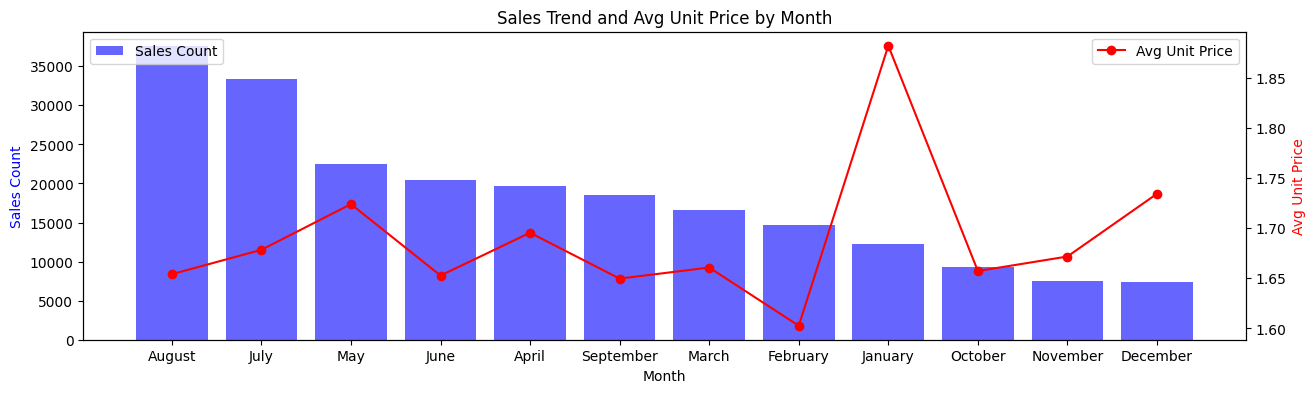

In [57]:
fig, ax1 = plt.subplots(figsize=(15, 4))  # Reduce width, increase height

ax2 = ax1.twinx()
ax1.bar(Sales_Trend_By_Month['Month'], Sales_Trend_By_Month['ticket_number'], color='blue', alpha=0.6, label='Sales Count')
ax2.plot(Sales_Trend_By_Month['Month'], Sales_Trend_By_Month['unit_price'], marker='o', color='red', label='Avg Unit Price')

ax1.set_xlabel('Month')
ax1.set_ylabel('Sales Count', color='blue')
ax2.set_ylabel('Avg Unit Price', color='red')

plt.title('Sales Trend and Avg Unit Price by Month')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.xticks(rotation=45)  # Rotate for better readability

plt.show()


This visualization shows **Sales Count** (blue bars) and **Average Unit Price** (red line) per month. Here are some insights:

### **1️⃣ Sales Trends**
- **Highest Sales**: August and July had the highest sales count.
- **Lowest Sales**: January and February had the lowest sales.
- **Mid-Year Drop**: Sales declined after July and remained lower for the rest of the year.

### **2️⃣ Price Trends**
- **Price Surge in January**: A **sharp increase** in **average unit price** in January.
- **Lowest Prices in February**: Prices dropped significantly right after the January peak.
- **Gradual Increase Toward Year-End**: Prices slightly increased from October to December.

### **3️⃣ Potential Business Insights**
- **Seasonality**: Sales peak in mid-year (August, July), possibly due to seasonal demand.
- **Price Elasticity**: Higher prices in January didn't lead to higher sales.  
  → Suggests demand is **price-sensitive**.
- **End-of-Year Strategy**: If higher prices work in January but not in other months, **consider promotions or price adjustments**.

Would you like help generating more detailed analysis? 🚀

In [58]:
df.head()

,date,ticket_number,item,Quantity,unit_price,Hour,Minute,Week_Day,Month,year,Revenue
0,2021-01-02,150040.0,BAGUETTE,1.0,0.90,8,38,Saturday,January,2021,0.90
1,2021-01-02,150040.0,PAIN AU CHOCOLAT,3.0,1.20,8,38,Saturday,January,2021,3.60
2,2021-01-02,150041.0,PAIN AU CHOCOLAT,2.0,1.20,9,14,Saturday,January,2021,2.40
3,2021-01-02,150041.0,PAIN,1.0,1.15,9,14,Saturday,January,2021,1.15
5,2021-01-02,150043.0,BAGUETTE,2.0,0.90,9,25,Saturday,January,2021,1.80


# Top Revenue Products

In [59]:
top_20_Most_Revenue_Products  = df.groupby('item').agg({'Revenue':'sum'}).reset_index().head(20).sort_values(by='Revenue',ascending=False).head(20)

In [60]:
top_20_Most_Revenue_Products

,item,Revenue
7,BANETTE,21199.95
4,BAGUETTE,17278.90
14,BRIOCHE,9274.00
12,BOULE 400G,7153.60
11,BOULE 200G,3405.65
9,BOISSON 33CL,2727.00
6,BAGUETTE GRAINE,2439.20
8,BANETTINE,1912.70
13,BOULE POLKA,868.00
1,12 MACARON,700.00


C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_7012\1884981006.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_Most_Revenue_Products, x="Revenue", y="item", palette="Blues_r")


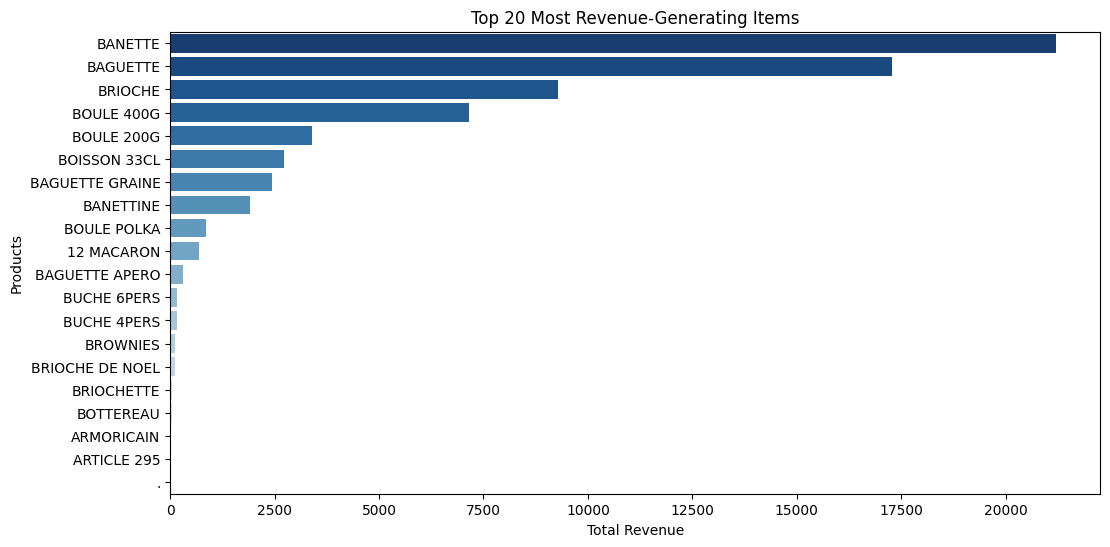

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=top_20_Most_Revenue_Products, x="Revenue", y="item", palette="Blues_r")
plt.xlabel("Total Revenue")
plt.ylabel("Products")
plt.title("Top 20 Most Revenue-Generating Items")
plt.show()


In [62]:
df.head()

,date,ticket_number,item,Quantity,unit_price,Hour,Minute,Week_Day,Month,year,Revenue
0,2021-01-02,150040.0,BAGUETTE,1.0,0.90,8,38,Saturday,January,2021,0.90
1,2021-01-02,150040.0,PAIN AU CHOCOLAT,3.0,1.20,8,38,Saturday,January,2021,3.60
2,2021-01-02,150041.0,PAIN AU CHOCOLAT,2.0,1.20,9,14,Saturday,January,2021,2.40
3,2021-01-02,150041.0,PAIN,1.0,1.15,9,14,Saturday,January,2021,1.15
5,2021-01-02,150043.0,BAGUETTE,2.0,0.90,9,25,Saturday,January,2021,1.80


In [63]:
df.groupby(['item','Month']).agg({'ticket_number':'count'}).reset_index().sort_values(by='ticket_number',ascending=False).head(20)

,item,Month,ticket_number
1049,TRADITIONAL BAGUETTE,August,11697
1053,TRADITIONAL BAGUETTE,July,9659
1056,TRADITIONAL BAGUETTE,May,6353
1054,TRADITIONAL BAGUETTE,June,5746
1048,TRADITIONAL BAGUETTE,April,5532
1059,TRADITIONAL BAGUETTE,September,5299
1055,TRADITIONAL BAGUETTE,March,4535
1051,TRADITIONAL BAGUETTE,February,4014
248,COUPE,August,3441
252,COUPE,July,3267


# Thanks